## Settings

In [46]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [47]:
## libraries
import sys
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators

## constants
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)

## Initialization

In [48]:
## reproducibility
N_DECIMALS   = 2
N_REPEATS    = 30
RANDOM_STATE = 42

## load data and models
data   = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Universality of Network Capacity

Three converging lines of evidence establish that event capacity is a fundamental invariant of complex networks — not an artefact of measurement, modelling, or domain-specific context.

**Rows (resampling regimes):** Each row evaluates a generalization condition.
- *Domain LOGO*: One scientific domain (5 total) is withheld entirely from training; the frontier is evaluated on observations the model has never encountered at the domain level.
- *Discipline LOGO*: One scientific discipline (25 total) is withheld from training, the hardest group-out condition in the study.
- *Random 5-Fold / Random 10-Fold*: Shuffled split baselines used to contextualize whether held-out-group transfer materially degrades the frontier.

**Columns (learning paradigms):** Each column represents a methodologically distinct estimator family. Stability across columns demonstrates that the recovered ordering is not a consequence of any particular modelling choice.

**Panels:** Each panel shows the per-discipline median estimated frontier (`y`) against the per-discipline median observed capacity (`x`). Points are colored by scientific domain; the grey dashed diagonal is the locus of perfect frontier equality ($\hat{y} = y$). Points above the diagonal indicate a valid frontier (the estimated bound encloses observations); red `x` markers indicate constraint violations. Efficiency Index (`EI`) and Composite Index (`CI`) are annotated per panel and computed from all valid observations, not from the displayed median dots.

**What to look for:** (i) Tight scatter near the diagonal in every panel — the frontier is accurate. (ii) The scatter is stable across columns — the frontier is paradigm-robust. (iii) The held-out rows remain comparable to random-split baselines — the frontier transfers to unseen groups without material degradation. Together, these invariances establish that network event capacity is a universal structural law accessible to any sufficiently expressive learner.

In [49]:
## ═══════════════════════════════════════════════════════════════════════════
## LEGACY ALL-IN-ONE UNIVERSALITY CELL — DISABLED
##
## This older cell trained models and rendered the figure in one pass. It is
## intentionally disabled so visual edits do not trigger retraining.
##
## Use the workflow below instead:
##   1. Run the COMPUTE cell only when data, features, models, resampling
##      regimes, or RANDOM_STATE change, or when RECOMPUTE = True.
##   2. Edit and rerun the RENDER cell freely for visual changes. It loads
##      outputs/cache/universality_paradigm_preds.pkl when needed.
## ═══════════════════════════════════════════════════════════════════════════

print("Legacy universality training/render cell disabled. Use COMPUTE once, then rerun RENDER for visual edits.")


Legacy universality training/render cell disabled. Use COMPUTE once, then rerun RENDER for visual edits.


## Visualization Workflow
Run the **COMPUTE** cell only when the data, features, model set, resampling regimes, or `RANDOM_STATE` change. For ordinary plot tweaks, edit and rerun only the **RENDER ONLY** cell; it uses cached predictions from `outputs/cache/universality_paradigm_preds.pkl` and does not call the training pipeline.

In [50]:
## ═══════════════════════════════════════════════════════════════════════════
## UNIVERSALITY BY LEARNING PARADIGM AND RESAMPLING REGIME — COMPUTE
##
## Computes per-model OOF predictions across regimes and aggregates them
## into paradigm groups. Results are cached to disk so re-running this cell
## (or restarting the kernel) is near-instant after the first run, and the
## render cell below can be iterated on without retraining.
##
## For visual edits, skip this cell and rerun the RENDER cell below.
## To force recompute: set RECOMPUTE = True, or delete the cache file.
## ═══════════════════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut, KFold
from sklearn.base import clone

from src.evaluators.training import fit_predict_frontier
from src.visualizers.visualizing import (
    DEFAULT_PARADIGM_ORDER,
    DEFAULT_MODEL_TO_PARADIGM,
)

## ─── cache control ──────────────────────────────────────────────────────────
RECOMPUTE  = False
CACHE_DIR  = "outputs/cache"
CACHE_PATH = os.path.join(CACHE_DIR, "universality_paradigm_preds.pkl")

## ─── resampling regimes ─────────────────────────────────────────────────────
REGIMES = [
    ("domain_logo", "Domain\nLOGO"),
    ("disc_logo",   "Discipline\nLOGO"),
    ("kfold_5",     "Random\n5-Fold"),
    ("kfold_10",    "Random\n10-Fold"),
]

## ─── paradigm groups ────────────────────────────────────────────────────────
PARADIGM_ORDER = list(DEFAULT_PARADIGM_ORDER)
PARADIGM_TO_MODELS = {p: [] for p in PARADIGM_ORDER}
for mn in models.keys():
    p = DEFAULT_MODEL_TO_PARADIGM.get(mn)
    if p is not None and p in PARADIGM_TO_MODELS:
        PARADIGM_TO_MODELS[p].append(mn)

## ─── load cache if present ──────────────────────────────────────────────────
viz_preds_par = {}
if not RECOMPUTE and os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as fh:
        cached = pickle.load(fh)
    if cached.get("n_obs") == len(data) and cached.get("random_state") == RANDOM_STATE:
        viz_preds_par = cached.get("viz_preds_par", {})
        print(f"Loaded cache: {len(viz_preds_par)} (model, regime) entries from {CACHE_PATH}")
    else:
        print("Cache invalid (data shape or random state changed); recomputing.")

## ─── OOF helpers ────────────────────────────────────────────────────────────
_n_rep = min(10, N_REPEATS)

def _logo_oof(grp_arr, mo):
    yp  = np.full(len(data), np.nan)
    loo = LeaveOneGroupOut()
    for tri, tei in loo.split(data, groups=grp_arr):
        tr  = data.iloc[tri].reset_index(drop=True)
        te  = data.iloc[tei].reset_index(drop=True)
        fit = fit_predict_frontier(
            data         = tr,
            feat_x       = FEAT_X,
            feat_z       = FEAT_Z,
            estimator_c  = clone(mo.estimator_c),
            estimator_r  = clone(mo.estimator_r),
            target       = TARGET,
            n_repeat     = _n_rep,
            random_state = RANDOM_STATE,
        )
        yp[tei] = fit_predict_frontier(data=te, fit_result=fit)["y_pred"]
    return yp

def _kfold_oof(n_splits, mo):
    yp = np.full(len(data), np.nan)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tri, tei in kf.split(data):
        tr  = data.iloc[tri].reset_index(drop=True)
        te  = data.iloc[tei].reset_index(drop=True)
        fit = fit_predict_frontier(
            data         = tr,
            feat_x       = FEAT_X,
            feat_z       = FEAT_Z,
            estimator_c  = clone(mo.estimator_c),
            estimator_r  = clone(mo.estimator_r),
            target       = TARGET,
            n_repeat     = _n_rep,
            random_state = RANDOM_STATE,
        )
        yp[tei] = fit_predict_frontier(data=te, fit_result=fit)["y_pred"]
    return yp

dom_arr_full  = data["domain"].to_numpy()
disc_arr_full = data["discipline"].to_numpy()

## ─── compute only what's missing from the cache ─────────────────────────────
needed_keys = [(mn, rk) for mn in models.keys() for rk, _ in REGIMES]
missing     = [k for k in needed_keys if k not in viz_preds_par]

if missing:
    print(f"Computing {len(missing)} missing (model, regime) entries...")
    for mn, mo in models.items():
        todo = [rk for rk, _ in REGIMES if (mn, rk) not in viz_preds_par]
        if not todo:
            continue
        print(f"  {mn}: {todo}", flush=True)
        for rk in todo:
            if rk == "domain_logo":
                ## reuse cached domain LOGO from prior cell if available
                if "viz_preds" in globals() and (mn, "domain_logo") in viz_preds:
                    viz_preds_par[(mn, rk)] = viz_preds[(mn, "domain_logo")]
                else:
                    viz_preds_par[(mn, rk)] = _logo_oof(dom_arr_full, mo)
            elif rk == "disc_logo":
                if "viz_preds" in globals() and (mn, "disc_logo") in viz_preds:
                    viz_preds_par[(mn, rk)] = viz_preds[(mn, "disc_logo")]
                else:
                    viz_preds_par[(mn, rk)] = _logo_oof(disc_arr_full, mo)
            elif rk == "kfold_5":
                viz_preds_par[(mn, rk)] = _kfold_oof(5, mo)
            elif rk == "kfold_10":
                viz_preds_par[(mn, rk)] = _kfold_oof(10, mo)

    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(CACHE_PATH, "wb") as fh:
        pickle.dump(
            dict(
                viz_preds_par = viz_preds_par,
                n_obs         = len(data),
                random_state  = RANDOM_STATE,
                regimes       = REGIMES,
                paradigm_order = PARADIGM_ORDER,
                paradigm_to_models = PARADIGM_TO_MODELS,
            ),
            fh,
        )
    print(f"Saved cache → {CACHE_PATH}")
else:
    print("All (model, regime) entries available; no computation needed.")

## ─── aggregate base learners → paradigm via per-observation median ──────────
viz_preds_par_agg = {}            ## (paradigm, regime) -> y_pred array
for p in PARADIGM_ORDER:
    member_models = PARADIGM_TO_MODELS[p]
    for rkey, _ in REGIMES:
        stacked = np.vstack([viz_preds_par[(m, rkey)] for m in member_models])
        viz_preds_par_agg[(p, rkey)] = np.nanmedian(stacked, axis=0)

print("Done.")

Loaded cache: 36 (model, regime) entries from outputs/cache/universality_paradigm_preds.pkl
All (model, regime) entries available; no computation needed.
Done.


Using in-memory cached predictions; render-only cell will not retrain.


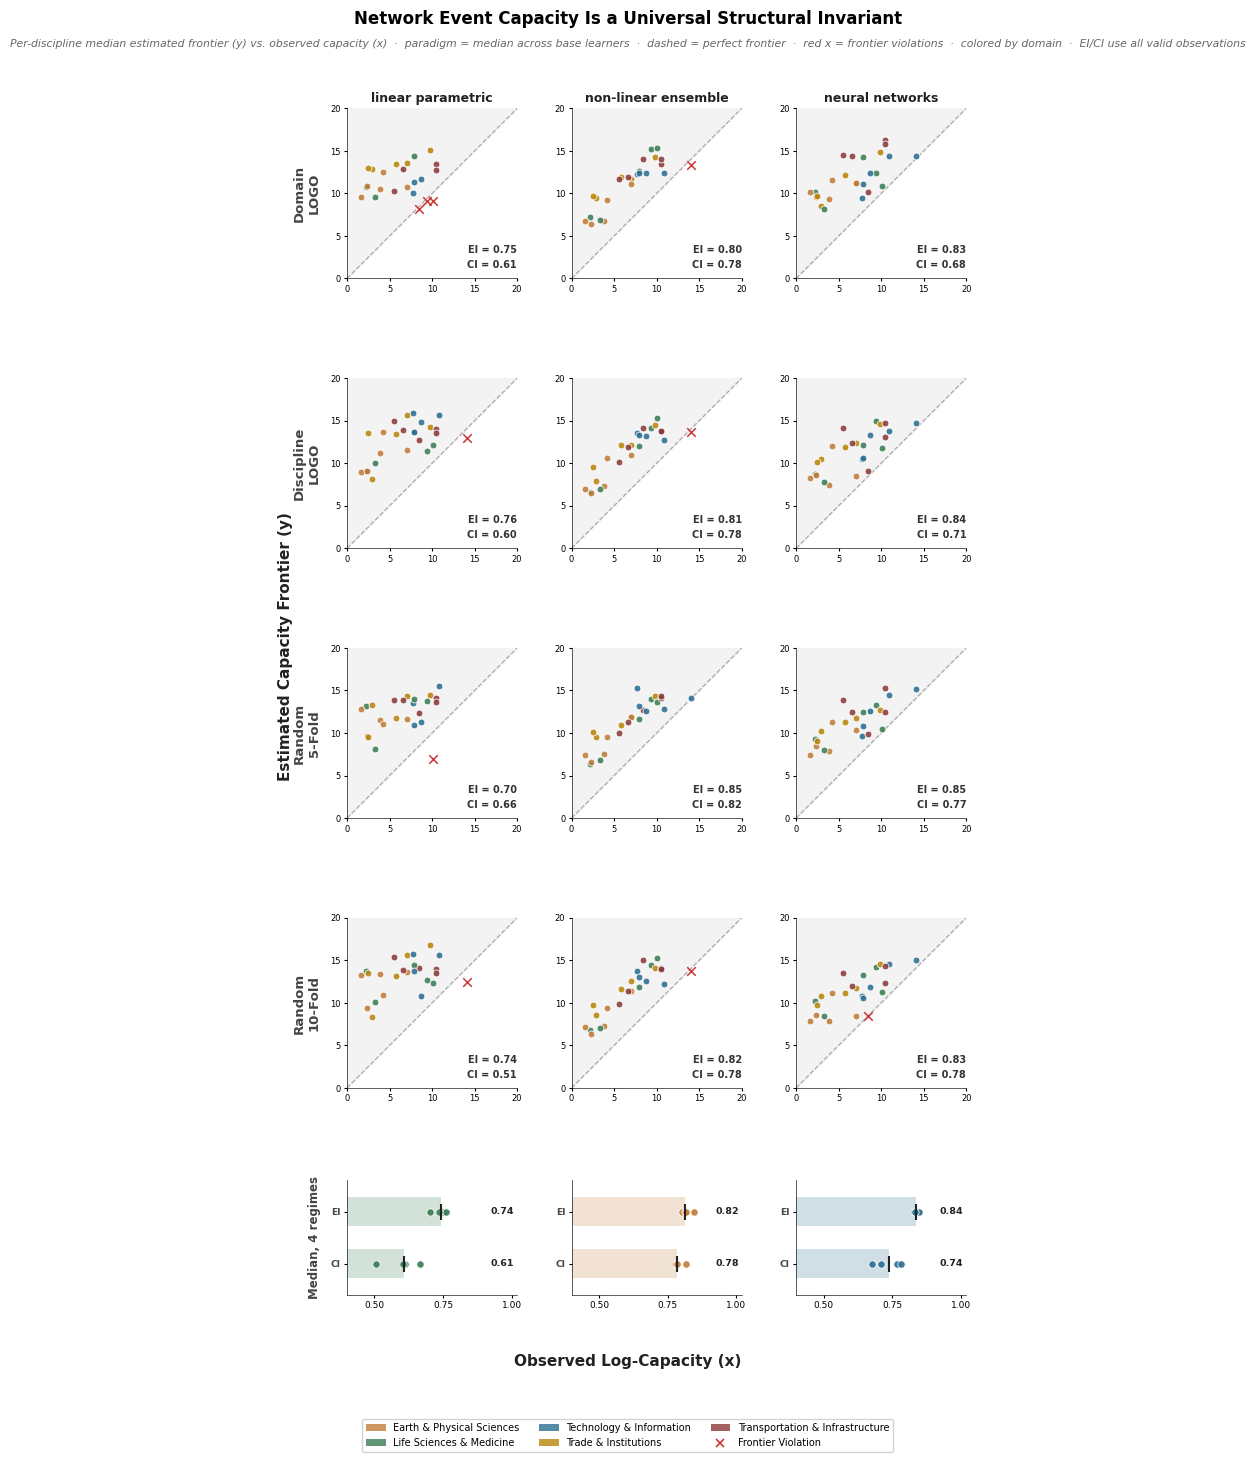

In [60]:
## ═══════════════════════════════════════════════════════════════════════════
## UNIVERSALITY BY LEARNING PARADIGM AND RESAMPLING REGIME — RENDER ONLY
##
## Pure visualization. Edit and rerun this cell freely for layout, labeling,
## colors, annotations, marker styling, or export settings. It never trains.
## If `viz_preds_par_agg` is not already in memory, it loads cached predictions
## from outputs/cache/universality_paradigm_preds.pkl and aggregates them.
## ═══════════════════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from src.evaluators.metrics import _efficiency_index, consensus_metrics
from src.vectorizers.scalers import _log_transformer
from src.visualizers.visualizing import (
    DEFAULT_PARADIGM_ORDER,
    DEFAULT_MODEL_TO_PARADIGM,
)

## ─── cache-backed prediction loading ────────────────────────────────────────
CACHE_DIR = "outputs/cache"
CACHE_PATH = os.path.join(CACHE_DIR, "universality_paradigm_preds.pkl")

REGIMES = [
    ("domain_logo", "Domain\nLOGO"),
    ("disc_logo",   "Discipline\nLOGO"),
    ("kfold_5",     "Random\n5-Fold"),
    ("kfold_10",    "Random\n10-Fold"),
]
PARADIGM_ORDER = list(DEFAULT_PARADIGM_ORDER)
PARADIGM_TO_MODELS = {p: [] for p in PARADIGM_ORDER}
for mn in models.keys():
    paradigm = DEFAULT_MODEL_TO_PARADIGM.get(mn)
    if paradigm is not None and paradigm in PARADIGM_TO_MODELS:
        PARADIGM_TO_MODELS[paradigm].append(mn)

if "viz_preds_par_agg" not in globals():
    if not os.path.exists(CACHE_PATH):
        raise FileNotFoundError(
            f"Cached predictions not found at {CACHE_PATH}. "
            "Run the COMPUTE cell once, then rerun this render cell."
        )
    with open(CACHE_PATH, "rb") as fh:
        cached = pickle.load(fh)
    if cached.get("n_obs") != len(data) or cached.get("random_state") != RANDOM_STATE:
        raise RuntimeError(
            "Cached predictions were produced for a different data shape or RANDOM_STATE. "
            "Rerun the COMPUTE cell with RECOMPUTE = True."
        )

    viz_preds_par = cached.get("viz_preds_par", {})
    missing_keys = [
        (model_name, regime_key)
        for model_name in models.keys()
        for regime_key, _ in REGIMES
        if (model_name, regime_key) not in viz_preds_par
    ]
    if missing_keys:
        preview = missing_keys[:5]
        raise RuntimeError(
            f"Cached predictions are missing {len(missing_keys)} model/regime entries; "
            f"examples: {preview}. Rerun the COMPUTE cell."
        )

    viz_preds_par_agg = {}
    for paradigm in PARADIGM_ORDER:
        member_models = PARADIGM_TO_MODELS[paradigm]
        if not member_models:
            continue
        for regime_key, _ in REGIMES:
            stacked = np.vstack([viz_preds_par[(model_name, regime_key)] for model_name in member_models])
            viz_preds_par_agg[(paradigm, regime_key)] = np.nanmedian(stacked, axis = 0)
    print(f"Loaded cached predictions from {CACHE_PATH}; render-only cell will not retrain.")
else:
    print("Using in-memory cached predictions; render-only cell will not retrain.")

## ─── domain palette ──────────────────────────────────────────────────────────
DOMAIN_PALETTE = {
    "Earth & Physical Sciences":       "#C07D3A",
    "Life Sciences & Medicine":        "#3A7D55",
    "Technology & Information":        "#2C6E91",
    "Trade & Institutions":            "#B8860B",
    "Transportation & Infrastructure": "#8B3A3A",
}

_par_palette = {
    "linear parametric":   "#3A7D55",
    "non-linear ensemble": "#C07D3A",
    "neural networks":     "#2C6E91",
}

## ─── figure geometry ─────────────────────────────────────────────────────────
##   Per-row inch factor is tuned so each scatter panel (aspect = equal,
##   adjustable = box) renders square at the FULL gridspec column width. That
##   in turn forces the bottom summary panels (no aspect constraint) to render
##   at the exact same column width — column-wise alignment between the
##   scatter grid and the summary strip falls out of the gridspec geometry.
n_col = len(PARADIGM_ORDER)
n_row = len(REGIMES)
SUMMARY_ROW_RATIO = 0.62

fig, axes = plt.subplots(
    n_row + 1, n_col,
    figsize     = (n_col * 2.40, (n_row + SUMMARY_ROW_RATIO) * 2.80 + 1.80),
    gridspec_kw = dict(
        height_ratios = [1.0] * n_row + [SUMMARY_ROW_RATIO],
        hspace        = 0.50,
        wspace        = 0.32,
    ),
    squeeze = False,
)
fig.subplots_adjust(top = 0.92, left = 0.11, right = 0.97, bottom = 0.11)

## ─── super-title + subtitle ──────────────────────────────────────────────────
fig.text(
    0.50, 0.982,
    "Network Event Capacity Is a Universal Structural Invariant",
    ha = "center", va = "top",
    fontsize = 12, fontweight = "bold",
    transform = fig.transFigure,
)
fig.text(
    0.50, 0.962,
    "Per-discipline median estimated frontier (y) vs. observed capacity (x)  ·  "
    "paradigm = median across base learners  ·  "
    "dashed = perfect frontier  ·  red x = frontier violations  ·  colored by domain  ·  "
    "EI/CI use all valid observations",
    ha = "center", va = "top",
    fontsize = 7.8, color = "#666", fontstyle = "italic",
    transform = fig.transFigure,
)

## ─── per-observation arrays ──────────────────────────────────────────────────
y_log    = _log_transformer(data[TARGET]).to_numpy(dtype = float)
dom_arr  = data["domain"].to_numpy()
disc_arr = data["discipline"].to_numpy()
discs    = np.unique(disc_arr)

## ─── precompute per-panel discipline-median points ──────────────────────────
panel_points = {}    ## (regime, paradigm) -> (xt_d, xp_d, clr_d)
for regime_key, _ in REGIMES:
    for paradigm in PARADIGM_ORDER:
        yp = viz_preds_par_agg[(paradigm, regime_key)]
        vm = np.isfinite(y_log) & np.isfinite(yp)

        xt_d, xp_d, clr_d = [], [], []
        for disc in discs:
            dm = (disc_arr == disc) & vm
            if not dm.any():
                continue
            xt_d.append(np.median(y_log[dm]))
            xp_d.append(np.median(yp[dm]))
            clr_d.append(DOMAIN_PALETTE.get(dom_arr[dm][0], "#888888"))

        panel_points[(regime_key, paradigm)] = (
            np.array(xt_d, dtype = float),
            np.array(xp_d, dtype = float),
            clr_d,
        )

SHARED_XL = 0.0
SHARED_XH = 20.0
SHARED_TICKS = np.linspace(SHARED_XL, SHARED_XH, 5)

## ─── scatter panel loop ──────────────────────────────────────────────────────
panel_metrics = {}    ## (regime, paradigm) -> {"ei": float, "ci": float}

for row_index, (regime_key, regime_label) in enumerate(REGIMES):
    for column_index, paradigm in enumerate(PARADIGM_ORDER):
        axis = axes[row_index, column_index]
        yp = viz_preds_par_agg[(paradigm, regime_key)]

        vm = np.isfinite(y_log) & np.isfinite(yp)
        xt_f = y_log[vm]
        xp_f = yp[vm]

        ei = _efficiency_index(y_true = xt_f, y_pred = xp_f)
        capacity_ci = consensus_metrics(y_true = xt_f, y_pred = xp_f)["ci"]
        panel_metrics[(regime_key, paradigm)] = {"ei": ei, "ci": capacity_ci}

        xt_d, xp_d, clr_d = panel_points[(regime_key, paradigm)]
        viol = xp_d < xt_d

        axis.set_xlim(SHARED_XL, SHARED_XH)
        axis.set_ylim(SHARED_XL, SHARED_XH)
        axis.set_xticks(SHARED_TICKS)
        axis.set_yticks(SHARED_TICKS)

        xx = np.array([SHARED_XL, SHARED_XH])
        axis.fill_between(xx, xx, SHARED_XH, color = "#F3F3F3", zorder = 0, clip_on = True)
        axis.plot(xx, xx, color = "#AAAAAA", lw = 0.9, ls = "--", zorder = 1)

        for point_index in range(len(xt_d)):
            if viol[point_index]:
                axis.scatter(
                    xt_d[point_index], xp_d[point_index],
                    marker = "x",
                    c = "#CC3333",
                    s = 38,
                    alpha = 0.95,
                    linewidths = 1.15,
                    zorder = 5,
                )
            else:
                axis.scatter(
                    xt_d[point_index], xp_d[point_index],
                    marker = "o",
                    c = clr_d[point_index],
                    s = 24,
                    alpha = 0.88,
                    linewidths = 0.65,
                    edgecolors = "white",
                    zorder = 4,
                )

        ## right-edge of label flush with right spine = highest x-axis point
        axis.text(
            1.0, 0.05,
            f"EI = {ei:.2f}\nCI = {capacity_ci:.2f}",
            transform = axis.transAxes,
            ha = "right", va = "bottom",
            fontsize = 7.0,
            fontweight = "semibold",
            color = "#333333",
            linespacing = 1.6,
        )

        axis.set_aspect("equal", adjustable = "box")
        axis.spines[["top", "right"]].set_visible(False)
        axis.spines[["bottom", "left"]].set_linewidth(0.45)
        axis.tick_params(labelsize = 6.0, pad = 2, length = 2.5)

        if row_index == 0:
            axis.set_title(
                paradigm,
                fontsize = 9.0,
                fontweight = "semibold",
                pad = 5,
                color = "#222222",
            )

    axes[row_index, 0].set_ylabel(
        regime_label,
        fontsize = 9.5,
        fontweight = "semibold",
        color = "#444444",
        labelpad = 7,
    )

## ─── paradigm-wise summary strip (bottom row) ───────────────────────────────
##   one panel per paradigm column. Two lanes per panel: EI on top, CI below.
##   Bar = median across the four resampling regimes.
##   Dots overlaid = per-regime values. Tight clustering of dots = the
##   paradigm's frontier quality is universal w.r.t. how the data are split.
SUMMARY_XLIM = (0.40, 1.02)

for column_index, paradigm in enumerate(PARADIGM_ORDER):
    summary_axis = axes[n_row, column_index]
    color = _par_palette[paradigm]

    ei_vals = np.array([panel_metrics[(rk, paradigm)]["ei"] for rk, _ in REGIMES])
    ci_vals = np.array([panel_metrics[(rk, paradigm)]["ci"] for rk, _ in REGIMES])
    median_ei = float(np.median(ei_vals))
    median_ci = float(np.median(ci_vals))

    ## faint median bars
    summary_axis.barh(
        [1, 0], [median_ei, median_ci],
        color  = color,
        alpha  = 0.22,
        height = 0.55,
        zorder = 2,
    )

    ## per-regime dots: the universality evidence
    for value in ei_vals:
        summary_axis.scatter(
            value, 1,
            c = color, s = 28, alpha = 0.92,
            edgecolors = "white", linewidths = 0.6, zorder = 4,
        )
    for value in ci_vals:
        summary_axis.scatter(
            value, 0,
            c = color, s = 28, alpha = 0.92,
            edgecolors = "white", linewidths = 0.6, zorder = 4,
        )

    ## median tick markers
    summary_axis.scatter(
        [median_ei, median_ci], [1, 0],
        marker = "|", c = "#222222", s = 130, lw = 1.5, zorder = 5,
    )

    ## numeric median annotation, right-aligned inside panel
    summary_axis.text(
        SUMMARY_XLIM[1] - 0.01, 1,
        f"{median_ei:.2f}",
        ha = "right", va = "center",
        fontsize = 6.8, fontweight = "semibold", color = "#222222",
    )
    summary_axis.text(
        SUMMARY_XLIM[1] - 0.01, 0,
        f"{median_ci:.2f}",
        ha = "right", va = "center",
        fontsize = 6.8, fontweight = "semibold", color = "#222222",
    )

    summary_axis.set_xlim(*SUMMARY_XLIM)
    summary_axis.set_ylim(-0.6, 1.6)
    summary_axis.set_yticks([1, 0])
    summary_axis.set_yticklabels(
        ["EI", "CI"],
        fontsize = 8.0, fontweight = "semibold", color = "#444444",
    )
    summary_axis.set_xticks([0.5, 0.75, 1.0])
    summary_axis.spines[["top", "right"]].set_visible(False)
    summary_axis.spines[["bottom", "left"]].set_linewidth(0.45)
    summary_axis.tick_params(labelsize = 6.5, pad = 2, length = 2.5)

axes[n_row, 0].set_ylabel(
    "Median, 4 regimes",
    fontsize = 8.5,
    fontweight = "semibold",
    color = "#444444",
    labelpad = 7,
)

## ─── shared axis labels ──────────────────────────────────────────────────────
fig.text(
    0.50, 0.060,
    "Observed Log-Capacity (x)",
    ha = "center", va = "bottom",
    fontsize = 11, fontweight = "semibold", color = "#222222",
)
fig.text(
    0.025, 0.55,
    "Estimated Capacity Frontier (y)",
    ha = "center", va = "center",
    fontsize = 11, fontweight = "semibold", rotation = 90, color = "#222222",
)

## ─── domain legend + violation key ──────────────────────────────────────────
leg_handles = [
    mpatches.Patch(facecolor = c, label = d, alpha = 0.80)
    for d, c in DOMAIN_PALETTE.items()
] + [
    Line2D(
        [], [], color = "#CC3333",
        marker = "x", linestyle = "None",
        markersize = 6.0, markeredgewidth = 1.2,
        label = "Frontier Violation",
    ),
]
fig.legend(
    handles        = leg_handles,
    loc            = "lower center",
    ncol           = 3,
    fontsize       = 7.0,
    framealpha     = 0.92,
    edgecolor      = "#D0D0D0",
    bbox_to_anchor = (0.50, 0.000),
)

## ─── save ────────────────────────────────────────────────────────────────────
os.makedirs("outputs/figures", exist_ok = True)
fig.savefig("outputs/figures/universality_paradigm.pdf", dpi = 300, bbox_inches = "tight")
fig.savefig("outputs/figures/universality_paradigm.png", dpi = 200, bbox_inches = "tight")
plt.show()